Imports

In [191]:
import os
import pandas as pd
from agcounts_filter import convert_AC 
import openpyxl
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

Infos à modifier

In [192]:
idx_premier_fichier = 0
idx_dernier_fichier = 4

file_path_non_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/Puissance/Puissance_1s_non_dom_04.06.02_MS_02.xlsx"
file_path_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/Puissance/Puissance_1s_dom_04.06.02_MS_02.xlsx"

# Ajuster la longueur de la fenetre glissante
time_window = 1 # fenetre de 1 secondes
time_window_10 = 1000

1. Récupération des AC et des annotations

In [ ]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les annotations vidéos
# Annotations all
Y_dom_all = []
Y_non_dom_all = []
# Annotations FAGA
Y_dom_faga = []
Y_non_dom_faga = []
# Annotations GA
Y_dom_ga = []
Y_non_dom_ga = []

#Parcourir les fichiers CSV
for file in folder[idx_premier_fichier:idx_dernier_fichier]:
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None
    allow_start_th = None

    previous_row_dom = 0
    previous_row_non_dom = 0
    previous_row_th = 0

    """******************************************************** 0. Récupération des infos : idx_file / ID / membre dom / non dom *******************************************************"""
    info_file = pd.read_csv(folder_path + "/Info_file.csv", sep = ',')
    file_row = idx_dernier_fichier / 4 - 1

    subject_id = info_file["subject_id"][file_row]
    dom_member = info_file["dom"][file_row]
    non_dom_member = info_file["non_dom"][file_row]

    """******************************************************** 1. Lecture des fichiers csv et récupération des données capteurs ******************************************************************************"""
    if extension == ".csv":

        # Conversion en AC 
        lst_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-6:-4] == non_dom_member:
            print("                                                                non_dom : ", non_dom_member)
            list_non_dom_x = lst_AC["Axis1"].tolist()
            list_non_dom_y = lst_AC["Axis2"].tolist()
            list_non_dom_z = lst_AC["Axis3"].tolist()

        elif file[-6:-4] == dom_member:
            print("                                                                dom : ", dom_member)
            list_dom_x = lst_AC["Axis1"].tolist()
            list_dom_y = lst_AC["Axis2"].tolist()
            list_dom_z = lst_AC["Axis3"].tolist()

        elif file[-6:-4] == "TH":
            list_th_x = lst_AC["Axis1"].tolist()
            list_th_y = lst_AC["Axis2"].tolist()
            list_th_z = lst_AC["Axis3"].tolist()

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de X ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{dom_member}" :
                row_start_dom = label.row
                # Cas ou le capteur dom est allumé en dernier
                if allow_start_non_dom and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) 
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value))
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{non_dom_member}" :
                row_start_non_dom = label.row
                # Cas ou le capteur non_dom est allumé en dernier
                if allow_start_dom and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #round
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True
            
            # thorax
            if label.value == "Start_Thorax" :
                row_start_th = label.row
                # Cas ou le capteur thorax est allumé en dernier
                if allow_start_dom and allow_start_non_dom :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value)) #
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_th = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            # Synchroniser X_dom et X_non_dom avec X_th
            if allow_start_dom and allow_start_non_dom and allow_start_th :
                
                # Récupération des labels dom
                if label.value[0:2] == dom_member:

                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 

                        for diff in range(0, difference):
                            Y_dom_ga.append(None)
                            Y_dom_faga.append(None)
                            Y_dom_all.append(None) #//////////////////////////////////////////////////////////// regarder ici : peut etre qu'il ne faut pas mettre de none dans les annotations

                    # *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                    for nb_sec in range(nb_repetitions): 
                        # GA
                        if label.value[-5:] == " V GA":
                            Y_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_ga.append(None)

                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_faga.append(None)

                        # all
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA": 
                            Y_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_dom = label.row


                # Récupération des labels non dom
                elif label.value[0:2] == non_dom_member:
                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                        for diff in range(0,difference):
                            Y_non_dom_ga.append(None)
                            Y_non_dom_faga.append(None)
                            Y_non_dom_all.append(None)
                            

                    #  *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                    for nb_sec in range(nb_repetitions): 

                        # GA 
                        if label.value[-5:] == " V GA":
                            Y_non_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_non_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_ga.append(None)
                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_non_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_non_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_faga.append(None)

                        # all    
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                            Y_non_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_non_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_non_dom = label.row

        # Suppression des données des capteurs enregistrées avant le start général (start de synchronisation)
        for sec_a_supp in range(decalage_start_dom):
            list_dom_x.pop(0)
            list_dom_y.pop(0)
            list_dom_z.pop(0)
        for sec_a_supp in range(decalage_start_non_dom):
            list_non_dom_x.pop(0)
            list_non_dom_y.pop(0)
            list_non_dom_z.pop(0)
        for sec_a_supp in range(decalage_start_th):
            list_th_x.pop(0)
            list_th_y.pop(0)
            list_th_z.pop(0)

        # Découpage de toutes les listes à la même longueur
        min_longueur = min(len(list_dom_x), len(list_non_dom_x), len(list_th_x), len(Y_dom_all), len(Y_non_dom_all))
        list_dom_x = list_dom_x[:min_longueur]
        list_dom_y = list_dom_y[:min_longueur]
        list_dom_z = list_dom_z[:min_longueur]
        list_non_dom_x = list_non_dom_x[:min_longueur]
        list_non_dom_y = list_non_dom_y[:min_longueur]
        list_non_dom_z = list_non_dom_z[:min_longueur]
        list_th_x = list_th_x[:min_longueur]
        list_th_y = list_th_y[:min_longueur]
        list_th_z = list_th_z[:min_longueur]
        Y_dom_all = Y_dom_all[:min_longueur]
        Y_non_dom_all = Y_non_dom_all[:min_longueur]
        Y_dom_faga = Y_dom_faga[:min_longueur]
        Y_non_dom_faga = Y_non_dom_faga[:min_longueur]
        Y_dom_ga = Y_dom_ga[:min_longueur]
        Y_non_dom_ga = Y_non_dom_ga[:min_longueur]
    

Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
list_dom_x = np.array(list_dom_x)
list_dom_y = np.array(list_dom_y)
list_dom_z = np.array(list_dom_z)
list_non_dom_x = np.array(list_non_dom_x)
list_non_dom_y = np.array(list_non_dom_y)
list_non_dom_z = np.array(list_non_dom_z)

On est dans le fichier : Data_231_LW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                dom :  LW
On est dans le fichier : Data_231_RW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                non_dom :  RW
On est dans le fichier : Data_231_TH.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_231_X.xlsx


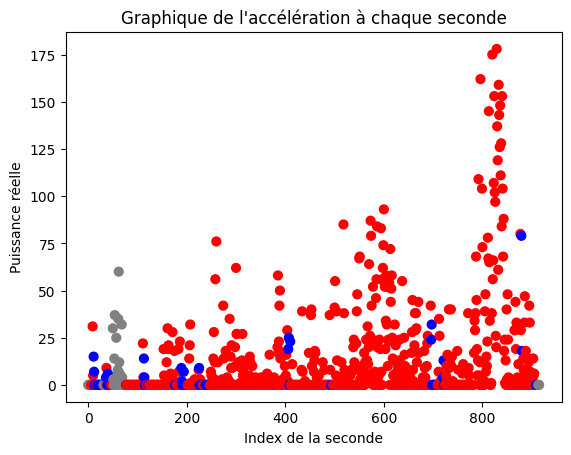

In [194]:

# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom_all]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(list_non_dom_z)), list_non_dom_z, c=colors, s=40)
plt.title("Graphique de l'accélération à chaque seconde")
plt.xlabel("Index de la seconde")
plt.ylabel("Puissance réelle")
plt.show()


2. Récupération des données gyroscopiques

In [195]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom_128_Hz = []
Y_gyro_dom_128_Hz = []
Z_gyro_dom_128_Hz = []
X_gyro_non_dom_128_Hz = []
Y_gyro_non_dom_128_Hz = []
Z_gyro_non_dom_128_Hz = []
# Initialisation des listes contenant les données des capteurs rééchantillonée à 1Hz
X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []

for file in folder[idx_premier_fichier:idx_dernier_fichier]:
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 11"]:
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 11"], dtype = {"Event":str},low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Pressure', 'Temperature', 'Event','Quat W', 'Quat X', 'Quat Y', 'Quat Z',"Unnamed: 14"]: 
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Pressure', 'Temperature', 'Event','Quat W', 'Quat X', 'Quat Y', 'Quat Z',"Unnamed: 14"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        if file[-6:-4] == non_dom_member:
            X_gyro_non_dom_128_Hz.extend(data_file["Gyro X"].astype(float).values.tolist()) 
            Y_gyro_non_dom_128_Hz.extend(data_file["Gyro Y"].astype(float).values.tolist()) 
            Z_gyro_non_dom_128_Hz.extend(data_file["Gyro Z"].astype(float).values.tolist())
        
        elif file[-6:-4] == dom_member:
            X_gyro_dom_128_Hz.extend(data_file["Gyro X"].astype(float).values.tolist()) 
            Y_gyro_dom_128_Hz.extend(data_file["Gyro Y"].astype(float).values.tolist()) 
            Z_gyro_dom_128_Hz.extend(data_file["Gyro Z"].astype(float).values.tolist())


for freq in range(0,len(X_gyro_dom_128_Hz),128):
    X_gyro_dom.append(np.mean(X_gyro_dom_128_Hz[freq:freq+128]))
    Y_gyro_dom.append(np.mean(Y_gyro_dom_128_Hz[freq:freq+128]))
    Z_gyro_dom.append(np.mean(Z_gyro_dom_128_Hz[freq:freq+128]))

for freq in range(0,len(X_gyro_non_dom_128_Hz),128):
    X_gyro_non_dom.append(np.mean(X_gyro_non_dom_128_Hz[freq:freq+128]))
    Y_gyro_non_dom.append(np.mean(Y_gyro_non_dom_128_Hz[freq:freq+128]))
    Z_gyro_non_dom.append(np.mean(Z_gyro_non_dom_128_Hz[freq:freq+128]))

print(len(X_gyro_dom))
# Suppression des données des capteurs enregistrées avant le start général (start de synchronisation)
for sec_a_supp in range(decalage_start_non_dom):
    X_gyro_non_dom.pop(0)
    Y_gyro_non_dom.pop(0)
    Z_gyro_non_dom.pop(0)
for sec_a_supp in range(decalage_start_dom):
    X_gyro_dom.pop(0)
    Y_gyro_dom.pop(0)
    Z_gyro_dom.pop(0)

print("décalage :", decalage_start_dom)
print(len(X_gyro_dom))

X_gyro_dom = np.array(X_gyro_dom[:min_longueur])
Y_gyro_dom = np.array(Y_gyro_dom[:min_longueur])
Z_gyro_dom = np.array(Z_gyro_dom[:min_longueur])
X_gyro_non_dom = np.array(X_gyro_non_dom[:min_longueur])
Y_gyro_non_dom = np.array(Y_gyro_non_dom[:min_longueur])
Z_gyro_non_dom = np.array(Z_gyro_non_dom[:min_longueur])

print(len(list_dom_x))
print(len(X_gyro_dom))

On est dans le fichier : Data_201_LW.csv
On est dans le fichier : Data_201_RW.csv
On est dans le fichier : Data_201_TH.csv
On est dans le fichier : Data_201_X.xlsx
795
décalage : 0
795
916
795


3. Calcul de la fenetre de puissance

In [196]:
lst_power_window_dom = []
lst_power_window_non_dom = []

print(len(list_dom_x))
for idx_window in range(0,min(len(list_dom_x)//time_window*time_window,len(list_non_dom_x)//time_window*time_window), time_window):
    
    # Range = moyenne_sur_la_fenetre
    # Récuépration des x sur la fenetre
    acc_x_dom = np.mean(list_dom_x[idx_window : idx_window + time_window])
    acc_x_non_dom = np.mean(list_non_dom_x[idx_window : idx_window + time_window])
    gyro_x_dom = np.mean(X_gyro_dom[idx_window : idx_window + time_window])
    gyro_x_non_dom = np.mean(X_gyro_non_dom[idx_window : idx_window + time_window])
    # Récuépration des y sur la fenetre
    acc_y_dom = np.mean(list_dom_y[idx_window : idx_window + time_window])
    acc_y_non_dom = np.mean(list_non_dom_y[idx_window : idx_window + time_window])
    gyro_y_dom = np.mean(Y_gyro_dom[idx_window : idx_window + time_window])
    gyro_y_non_dom = np.mean(Y_gyro_non_dom[idx_window : idx_window + time_window])
    # Récuépration des z sur la fenetre
    acc_z_dom = np.mean(list_dom_z[idx_window : idx_window + time_window])
    acc_z_non_dom = np.mean(list_non_dom_z[idx_window : idx_window + time_window])
    gyro_z_dom = np.mean(Z_gyro_dom[idx_window : idx_window + time_window])
    gyro_z_non_dom = np.mean(Z_gyro_non_dom[idx_window : idx_window + time_window])


    # Range = max_de_la_fenetre - min_de_la_fenetre
    """
    acc_x_dom = max(list_dom_x[idx_window : idx_window + time_window]) - min(list_dom_x[idx_window : idx_window + time_window])
    acc_x_non_dom = max(list_non_dom_x[idx_window : idx_window + time_window]) - min(list_non_dom_x[idx_window : idx_window + time_window])
    gyro_x_dom = max(X_gyro_dom[idx_window : idx_window + time_window]) - min(X_gyro_dom[idx_window : idx_window + time_window])
    gyro_x_non_dom = max(X_gyro_non_dom[idx_window : idx_window + time_window]) - min(X_gyro_non_dom[idx_window : idx_window + time_window])
    # Récupération des y sur la fenetre
    acc_y_dom = max(list_dom_y[idx_window : idx_window + time_window]) - min(list_dom_y[idx_window : idx_window + time_window])
    acc_y_non_dom = max(list_non_dom_y[idx_window : idx_window + time_window]) - min(list_non_dom_y[idx_window : idx_window + time_window])
    gyro_y_dom = max(Y_gyro_dom[idx_window : idx_window + time_window]) - min(Y_gyro_dom[idx_window : idx_window + time_window])
    gyro_y_non_dom = max(Y_gyro_non_dom[idx_window : idx_window + time_window]) - min(Y_gyro_non_dom[idx_window : idx_window + time_window])
    # Récupération des z sur la fenetre
    acc_z_dom = max(list_dom_z[idx_window : idx_window + time_window]) - min(list_dom_z[idx_window : idx_window + time_window])
    acc_z_non_dom = max(list_non_dom_z[idx_window : idx_window + time_window]) - min(list_non_dom_z[idx_window : idx_window + time_window])
    gyro_z_dom = max(Z_gyro_dom[idx_window : idx_window + time_window]) - min(Z_gyro_dom[idx_window : idx_window + time_window])
    gyro_z_non_dom = max(Z_gyro_non_dom[idx_window : idx_window + time_window]) - min(Z_gyro_non_dom[idx_window : idx_window + time_window])"""

    # Power window 
    power_window_dom = acc_x_dom * gyro_x_dom + acc_y_dom * gyro_y_dom + acc_z_dom * gyro_z_dom
    power_window_non_dom = acc_x_non_dom * gyro_x_non_dom + acc_y_non_dom * gyro_y_non_dom + acc_z_non_dom * gyro_z_non_dom

    for i in range(time_window):
        lst_power_window_dom.append(power_window_dom)
        lst_power_window_non_dom.append(power_window_non_dom)

print(len(lst_power_window_dom))
print(lst_power_window_dom)

lst_power_window_dom_10 = []
lst_power_window_non_dom_10 = []

print(len(list_dom_x))
for idx_window in range(0,min(len(list_dom_x)//time_window_10*time_window_10,len(list_non_dom_x)//time_window_10*time_window_10), time_window_10):
    
    # Range = moyenne_sur_la_fenetre
    # Récuépration des x sur la fenetre
    acc_x_dom_10 = np.mean(list_dom_x[idx_window : idx_window + time_window_10])
    acc_x_non_dom_10 = np.mean(list_non_dom_x[idx_window : idx_window + time_window_10])
    gyro_x_dom_10 = np.mean(X_gyro_dom[idx_window : idx_window + time_window_10])
    gyro_x_non_dom_10 = np.mean(X_gyro_non_dom[idx_window : idx_window + time_window_10])
    # Récuépration des y sur la fenetre
    acc_y_dom_10 = np.mean(list_dom_y[idx_window : idx_window + time_window_10])
    acc_y_non_dom_10 = np.mean(list_non_dom_y[idx_window : idx_window + time_window_10])
    gyro_y_dom_10 = np.mean(Y_gyro_dom[idx_window : idx_window + time_window_10])
    gyro_y_non_dom_10 = np.mean(Y_gyro_non_dom[idx_window : idx_window + time_window_10])
    # Récuépration des z sur la fenetre
    acc_z_dom_10 = np.mean(list_dom_z[idx_window : idx_window + time_window_10])
    acc_z_non_dom_10 = np.mean(list_non_dom_z[idx_window : idx_window + time_window_10])
    gyro_z_dom_10 = np.mean(Z_gyro_dom[idx_window : idx_window + time_window_10])
    gyro_z_non_dom_10 = np.mean(Z_gyro_non_dom[idx_window : idx_window + time_window_10])

    # Power window 
    power_window_dom_10 = acc_x_dom_10 * gyro_x_dom_10 + acc_y_dom_10 * gyro_y_dom_10 + acc_z_dom_10 * gyro_z_dom_10
    power_window_non_dom_10 = acc_x_non_dom_10 * gyro_x_non_dom_10 + acc_y_non_dom_10 * gyro_y_non_dom_10 + acc_z_non_dom_10 * gyro_z_non_dom_10

    for i in range(time_window_10):
        lst_power_window_dom_10.append(power_window_dom_10)
        lst_power_window_non_dom_10.append(power_window_non_dom_10)

print(len(lst_power_window_dom_10))
print(lst_power_window_dom_10)

916
916
[-1810.4767521875003, 149.63147828125057, -87.40428, -294.7323225, -6341.312276875, 3250.163213203125, -31.028460078124965, 1067.8464594531251, -950.8154920312501, 103.20816437499991, -2918.849182265625, -1399.2413873437501, 0.0, -74.8102765625, 0.0, -30.172938749999997, 0.0, 0.0, -54.60985960937501, -178.883256796875, -22.5958171875, -107.9180784375, 1253.11746546875, -212.49650031250002, -26.737732343750004, -1371.6657072656253, 0.0, 70.5489665625, 0.0, 0.0, -405.6268855468751, -336.518968046875, 1807.607927109375, -386.86951312499997, 3514.9334821875004, -1581.33698953125, 60.09991734375, 0.0, 0.0, 0.0, 0.0, 3.2145784375, -0.20570843749999668, 4.679155859375, 0.0, -4.66804265625, 0.0, -68.44664890625, 1454.6058642187497, 2101.8364664062497, -134.33752625, 113.94299164062502, -169.44665328125, -1231.4058834374998, -73.93399656249994, 75.354431171875, 150.238873828125, 0.0, -2024.799797734375, 1104.4256146874998, 16.810705156250005, 228.63954023437498, 98.786185546875, -415.87

c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


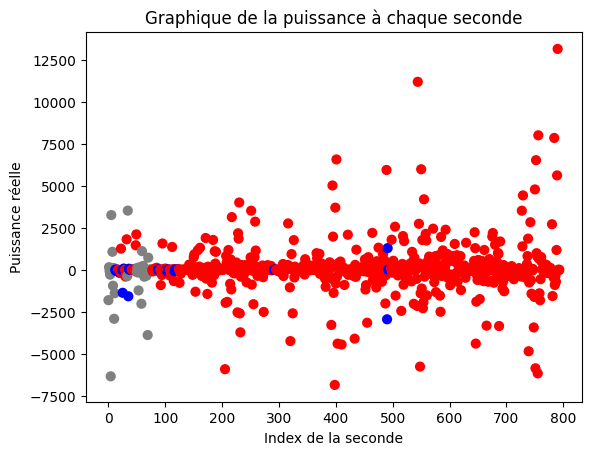

In [197]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_dom_all[:len(lst_power_window_dom)]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_dom)), lst_power_window_dom, c=colors, s=40)
plt.title("Graphique de la puissance à chaque seconde")
plt.xlabel("Index de la seconde")
plt.ylabel("Puissance réelle")
plt.show()


4. Nettoyage des données

In [198]:
total_list_dom_sec = np.arange(1,len(Y_dom_all)+1)
total_list_non_dom_sec = np.arange(1,len(Y_non_dom_all)+1)
lst_power_window_dom = np.array(lst_power_window_dom)
lst_power_window_non_dom = np.array(lst_power_window_non_dom)
lst_power_window_dom_10 = np.array(lst_power_window_dom_10)
lst_power_window_non_dom_10 = np.array(lst_power_window_non_dom_10)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_dom = Y_dom_all != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_non_dom = Y_non_dom_all != None

lst_power_window_dom = lst_power_window_dom[mask_dom[0:len(lst_power_window_dom)]]
lst_power_window_non_dom = lst_power_window_non_dom[mask_non_dom[0:len(lst_power_window_non_dom)]]
lst_power_window_dom_10 = lst_power_window_dom_10[mask_dom[0:len(lst_power_window_dom_10)]]
lst_power_window_non_dom_10 = lst_power_window_non_dom_10[mask_non_dom[0:len(lst_power_window_non_dom_10)]]
Y_dom_all = Y_dom_all[mask_dom]
Y_non_dom_all = Y_non_dom_all[mask_non_dom]
list_dom_sec =  total_list_dom_sec[mask_dom]
list_non_dom_sec = total_list_non_dom_sec[mask_non_dom]

print("len(Y_non_dom) après nettoyage :", len(Y_non_dom_all))

len(Y_non_dom) après nettoyage : 875


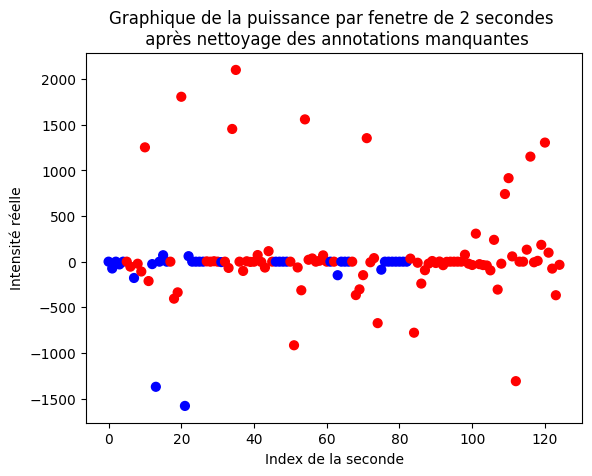

In [199]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_dom_all[:len(lst_power_window_dom[0:125])]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_dom[0:125])), lst_power_window_dom[0:125], c=colors, s=40)
plt.title("Graphique de la puissance par fenetre de 2 secondes \n après nettoyage des annotations manquantes")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()

In [200]:
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)


# GA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_dom = Y_dom_ga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_non_dom = Y_non_dom_ga != None

Y_dom_ga = Y_dom_ga[mask_ga_dom]
Y_non_dom_ga = Y_non_dom_ga[mask_ga_non_dom]

#FAGA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_dom = Y_dom_faga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_non_dom = Y_non_dom_faga != None

Y_dom_faga = Y_dom_faga[mask_faga_dom]
Y_non_dom_faga = Y_non_dom_faga[mask_faga_non_dom]


5. Prédiction du seuil

In [201]:
window_pred_dom = []
window_pred_non_dom = []
window_pred_dom_10 = []
window_pred_non_dom_10 = []

# Prediction for dominant member
for value in lst_power_window_dom:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_dom.append(1)
    else: #elif value == 0:
        window_pred_dom.append(0)

# Prediction for non dominant member
for value in lst_power_window_non_dom:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_non_dom.append(1)
    else: #elif value <= 0:
        window_pred_non_dom.append(0)

# Prediction for dominant member
for value in lst_power_window_dom_10:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_dom_10.append(1)
    else: #elif value == 0:
        window_pred_dom_10.append(0)

# Prediction for non dominant member
for value in lst_power_window_non_dom_10:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_non_dom_10.append(1)
    else: #elif value <= 0:
        window_pred_non_dom_10.append(0)

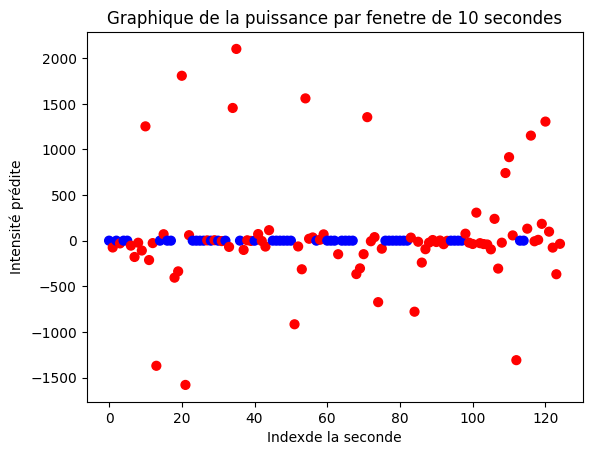

len(lst_power_window_dom) après nettoyage : 872


In [202]:
# Crée un mapping de couleur pour chaque label
label_to_color = {1: 'red', 0: 'blue', None : 'grey'}
colors = [label_to_color[y] for y in window_pred_dom[0:125]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_dom[0:125])), lst_power_window_dom[0:125], c=colors, s=40)
plt.title("Graphique de la puissance par fenetre de 10 secondes")
plt.xlabel("Indexde la seconde")
plt.ylabel("Intensité prédite")
plt.show()

print("len(lst_power_window_dom) après nettoyage :", len(lst_power_window_dom))


6. Accuracy et F1 scores

In [203]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)

# -------------------------------------------- Transformation des labels --------------------------------------------
# Transformation des labels GA
Y_dom_ga_int = np.where(Y_dom_ga == 'mouvement' , 1, 0)
Y_non_dom_ga_int = np.where(Y_non_dom_ga == "mouvement", 1, 0)

# Transformation des labels GA
Y_dom_faga_int = np.where(Y_dom_faga == "mouvement" , 1, 0)
Y_non_dom_faga_int = np.where(Y_non_dom_faga == "mouvement", 1, 0)

# Transformation des labels all
Y_dom_all_int = np.where(Y_dom_all == "mouvement" , 1, 0)
Y_non_dom_all_int = np.where(Y_non_dom_all == "mouvement", 1, 0)

# ---------------------------- lst_Y_pred sont des numpy int mais Y_dom_all sont des int : il faut convertir les numpy int pour qu'ils correspondent aux int ------------------------------
# ga
Y_dom_ga_int = np.array(Y_dom_ga_int, dtype=np.int32)
Y_non_dom_ga_int = np.array(Y_non_dom_ga_int, dtype=np.int32)

# all
Y_dom_faga_int = np.array(Y_dom_faga_int, dtype=np.int32)
Y_non_dom_faga_int = np.array(Y_non_dom_faga_int, dtype=np.int32)

# all
Y_dom_all_int = np.array(Y_dom_all_int, dtype=np.int32)
Y_non_dom_all_int = np.array(Y_non_dom_all_int, dtype=np.int32)

# -------------------------------------------- Accuracy ---------------------------------------------

# ga
accuracy_dom_ga_0 = accuracy_score(Y_dom_ga_int[:len(window_pred_dom)],window_pred_dom)
print("Accuracy dom ga : ", accuracy_dom_ga_0)
accuracy_non_dom_ga_0 = accuracy_score(Y_non_dom_ga_int[:len(window_pred_non_dom)],window_pred_non_dom)
print("Accuracy non dom ga : ", accuracy_non_dom_ga_0)
accuracy_dom_ga_10 = accuracy_score(Y_dom_ga_int[:len(window_pred_dom_10)],window_pred_dom_10)
print("Accuracy dom ga : ", accuracy_dom_ga_10)
accuracy_non_dom_ga_10 = accuracy_score(Y_non_dom_ga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10)
print("Accuracy non dom ga : ", accuracy_non_dom_ga_10)

# faga
accuracy_dom_faga_0 = accuracy_score(Y_dom_faga_int[:len(window_pred_dom)],window_pred_dom)
print("Accuracy dom faga : ", accuracy_dom_faga_0)
accuracy_non_dom_faga_0 = accuracy_score(Y_non_dom_faga_int[:len(window_pred_non_dom)],window_pred_non_dom)
print("Accuracy non dom faga : ", accuracy_non_dom_faga_0)
accuracy_dom_faga_10 = accuracy_score(Y_dom_faga_int[:len(window_pred_dom_10)],window_pred_dom_10)
print("Accuracy dom faga : ", accuracy_dom_faga_10)
accuracy_non_dom_faga_10 = accuracy_score(Y_non_dom_faga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10)
print("Accuracy non dom faga : ", accuracy_non_dom_faga_10)

# all
accuracy_dom_all_0 = accuracy_score(Y_dom_all_int[:len(window_pred_dom)],window_pred_dom)
print("Accuracy dom all : ", accuracy_dom_all_0)
accuracy_non_dom_all_0 = accuracy_score(Y_non_dom_all_int[:len(window_pred_non_dom)],window_pred_non_dom)
print("Accuracy non dom all : ", accuracy_non_dom_all_0)
accuracy_dom_all_10 = accuracy_score(Y_dom_all_int[:len(window_pred_dom_10)],window_pred_dom_10)
print("Accuracy dom all : ", accuracy_dom_all_10)
accuracy_non_dom_all_10 = accuracy_score(Y_non_dom_all_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10)
print("Accuracy non dom all : ", accuracy_non_dom_all_10)


# -------------------------------------------- F1 scores  ---------------------------------------------
# ga 
# 2AC > 0
f1_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 0 , average = "binary")
# 10AC > 10
f1_mvt_dom_ga_10 = f1_score(Y_dom_ga_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_10 = f1_score(Y_dom_ga_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_10 = f1_score(Y_non_dom_ga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_10 = f1_score(Y_non_dom_ga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 0 , average = "binary")

# faga
# 2AC > 0
f1_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 0 , average = "binary")
# 10AC > 10
f1_mvt_dom_faga_10 = f1_score(Y_dom_faga_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_10 = f1_score(Y_dom_faga_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_10 = f1_score(Y_non_dom_faga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_10 = f1_score(Y_non_dom_faga_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 0 , average = "binary")

# all
# 2AC > 0
f1_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(window_pred_dom)],window_pred_dom, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(window_pred_non_dom)],window_pred_non_dom, labels = [0,1], pos_label = 0 , average = "binary")
# 10AC > 10
f1_mvt_dom_all_10 = f1_score(Y_dom_all_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_10 = f1_score(Y_dom_all_int[:len(window_pred_dom_10)],window_pred_dom_10, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_10 = f1_score(Y_non_dom_all_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_10 = f1_score(Y_non_dom_all_int[:len(window_pred_non_dom_10)],window_pred_non_dom_10, labels = [0,1], pos_label = 0 , average = "binary")



Accuracy dom ga :  0.7660550458715596
Accuracy non dom ga :  0.6091428571428571
Accuracy dom ga :  nan
Accuracy non dom ga :  nan
Accuracy dom faga :  0.7649082568807339
Accuracy non dom faga :  0.5988571428571429
Accuracy dom faga :  nan
Accuracy non dom faga :  nan
Accuracy dom all :  0.7614678899082569
Accuracy non dom all :  0.5131428571428571
Accuracy dom all :  nan
Accuracy non dom all :  nan


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages

7. Enregistrement dans les excels

In [204]:
# Select file
if os.path.exists(file_path_dom):
    my_wb = openpyxl.load_workbook(file_path_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Puissance", "2s Puissance > 1 ", "10s Puissance > 1 ", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pas_pred in range(len(lst_power_window_dom_10)):
    my_cell = my_sheet.cell(row = idx_pas_pred + 2, column = 2)
    my_cell.value = lst_power_window_dom_10[idx_pas_pred]

# 3e colonne = prédiction fenetre de puissance> 0
for idx_pred_0 in range(len(window_pred_dom)):
    my_cell = my_sheet.cell(row = idx_pred_0 + 2, column = 3)
    my_cell.value = int(window_pred_dom[idx_pred_0])

# 4e colonne = prédiction fenetre de puissance> 0
for idx_pred_10 in range(len(window_pred_dom_10)):
    my_cell = my_sheet.cell(row = idx_pred_10 + 2, column = 4)
    my_cell.value = int(window_pred_dom_10[idx_pred_10])

# 5e colonne = Observation GA
for idx_obs_ga in range(len(Y_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 5)
    if Y_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 6e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 6)
    if Y_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 7e colonne = Observation All
for idx_obs_all in range(len(Y_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 7)
    if Y_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"


# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "2AC > 1"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga 2AC > 1"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga 2AC > 1"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all 2AC > 1"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga 2AC > 1"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row =9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga 2AC > 1"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all 2AC > 1"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga 2AC > 1"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga 2AC > 1"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all 2AC > 1"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_dom_all_0

my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_dom_all)



# Autres colonnes : accuracy et F1 scores modèle 2
my_cell_title = my_sheet.cell(row = 5, column = 16)
my_cell_title.value = "10AC > 1"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 16)
my_cell_title_acc_fa.value = "Accuracy ga 10AC > 1"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 17)
my_cell_title_acc_gafa.value = "Accuracy faga 10AC > 1"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 18)
my_cell_title_acc_all.value = "Accuracy all 10AC > 1"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 16)
my_cell_acc_ga.value = accuracy_dom_ga_10
my_cell_acc_faga = my_sheet.cell(row = 7, column = 17)
my_cell_acc_faga.value = accuracy_dom_faga_10
my_cell_acc_all = my_sheet.cell(row = 7, column = 18)
my_cell_acc_all.value = accuracy_dom_all_10

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 16)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 16)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga 10AC > 1"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row =9, column = 17)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga 10AC > 1"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 18)
my_cell_title_F1_mvt_all.value = "F1 mvt all 10AC > 1"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 16)
my_cell_F1_mvt_ga.value = f1_mvt_dom_ga_10
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 17)
my_cell_F1_mvt_faga.value = f1_mvt_dom_faga_10
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 18)
my_cell_F1_mvt_all.value = f1_mvt_dom_all_10

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 16)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 16)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga 10AC > 1"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 17)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga 10AC > 1"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 18)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all 10AC > 1"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 16)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_dom_ga_10
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 17)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_dom_faga_10
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 18)
my_cell_F1_non_mvt_all.value = f1_non_mvt_dom_all_10



my_wb.save(file_path_dom)

File exists, loading existing data.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne


In [205]:
# Select file
if os.path.exists(file_path_non_dom):
    my_wb = openpyxl.load_workbook(file_path_non_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Puissance", "2s Puissance > 1 ", "10s Puissance > 1 ", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_non_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_non_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pas_pred in range(len(lst_power_window_non_dom_10)):
    my_cell = my_sheet.cell(row = idx_pas_pred + 2, column = 2)
    my_cell.value = lst_power_window_non_dom_10[idx_pas_pred]


# 3e colonne = prédiction résultats fenetre de puissance > 0
for idx_pred_0 in range(len(window_pred_non_dom)):
    my_cell = my_sheet.cell(row = idx_pred_0 + 2, column = 3)
    my_cell.value = int(window_pred_non_dom[idx_pred_0])

# 4e colonne = prédiction résultats fenetre de puissance > 0
for idx_pred_10 in range(len(window_pred_non_dom_10)):
    my_cell = my_sheet.cell(row = idx_pred_10 + 2, column = 4)
    my_cell.value = int(window_pred_non_dom_10[idx_pred_10])

# 5e colonne = Observation GA
for idx_obs_ga in range(len(Y_non_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 5)
    if Y_non_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 6e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_non_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 6)
    if Y_non_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 7e colonne = Observation All
for idx_obs_all in range(len(Y_non_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 7)
    if Y_non_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"

# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "2AC > 0"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_non_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_non_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row = 9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_non_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_non_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_non_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_non_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_non_dom_all_0

# Autres colonnes : accuracy et F1 scores modèle 2
my_cell_title = my_sheet.cell(row = 5, column = 16)
my_cell_title.value = "10AC > 1"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 16)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 17)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 18)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 16)
my_cell_acc_ga.value = accuracy_non_dom_ga_10
my_cell_acc_faga = my_sheet.cell(row = 7, column = 17)
my_cell_acc_faga.value = accuracy_non_dom_faga_10
my_cell_acc_all = my_sheet.cell(row = 7, column = 18)
my_cell_acc_all.value = accuracy_non_dom_all_10

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 16)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 16)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row = 9, column = 17)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 18)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 16)
my_cell_F1_mvt_ga.value = f1_mvt_non_dom_ga_10
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 17)
my_cell_F1_mvt_faga.value = f1_mvt_non_dom_faga_10
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 18)
my_cell_F1_mvt_all.value = f1_mvt_non_dom_all_10

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 16)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 16)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 17)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 18)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 16)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_non_dom_ga_10
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 17)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_non_dom_faga_10
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 18)
my_cell_F1_non_mvt_all.value = f1_non_mvt_non_dom_all_10

my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_dom_all)

my_wb.save(file_path_non_dom)

File exists, loading existing data.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
